In [3]:
import bw2data, bw2io
#from premise import *
#import bw_timex
from bw_timex import TimexLCA
from bw_temporalis import TemporalDistribution, easy_timedelta_distribution
import numpy as np
from datetime import datetime

In [4]:
# activate the bw project
bw2data.projects.set_current("ei311")
#list(bw2data.databases)
for db in bw2data.databases:
    print(db, len(bw2data.Database(db)))

ecoinvent-3.11-biosphere 9795
ecoinvent-3.11-cutoff 25412
ei_cutoff_3.11_remind_SSP2-NDC_2030 2025-11-21 37360
ei_cutoff_3.11_remind_SSP2-NDC_2040 2025-11-21 37361
ei_cutoff_3.11_remind_SSP2-NDC_2050 2025-11-21 37361
ei_cutoff_3.11_image_SSP5-H_2030 2025-11-22 41755
ei_cutoff_3.11_image_SSP5-H_2040 2025-11-22 41759
ei_cutoff_3.11_image_SSP5-H_2050 2025-11-22 41762
ei_cutoff_3.11_image_SSP1-VLLO_2050 2025-11-22 41789
ei_cutoff_3.11_image_SSP2-M_2030 2025-11-22 41754
ei_cutoff_3.11_image_SSP1-VLLO_2040 2025-11-22 41789
ei_cutoff_3.11_image_SSP2-M_2040 2025-11-22 41759
ei_cutoff_3.11_image_SSP2-M_2050 2025-11-22 41762
ei_cutoff_3.11_image_SSP1-VLLO_2030 2025-11-24 41774
elec_foreground 1


In [5]:
image_ssp1_db_2030 = bw2data.Database("ei_cutoff_3.11_image_SSP1-VLLO_2030 2025-11-24")
image_ssp1_db_2040 = bw2data.Database("ei_cutoff_3.11_image_SSP1-VLLO_2040 2025-11-22")
image_ssp1_db_2050 = bw2data.Database("ei_cutoff_3.11_image_SSP1-VLLO_2050 2025-11-22")

In [110]:
elec_ssp1_2030_production = image_ssp1_db_2030.get(name="market group for electricity, high voltage", location="CAN")
print(elec_ssp1_2030_production)

'market group for electricity, high voltage' (kilowatt hour, CAN, None)


## create new foreground DB

In [147]:
if "elec_foreground" in bw2data.databases:
    del bw2data.databases["elec_foreground"]  
foreground = bw2data.Database("elec_foreground")
foreground.register()

In [148]:
elec_highvol_CAN_1kwh = foreground.new_node("high_voltage_elec_CAN", 
                                            name="electricity mix, high voltage, Canada", 
                                            location = "CAN", unit="kWh")

elec_highvol_CAN_1kwh['reference product'] = "one kWh electricity mix, high voltage"

elec_highvol_CAN_1kwh.new_edge(input=elec_highvol_CAN_1kwh, amount=1, type="production").save()


input_elec_to_highvol_CAN_1kwh = elec_highvol_CAN_1kwh.new_edge(
    input=elec_ssp1_2030_production,
    amount=1,
    type="technosphere",
)#.save()


elec_highvol_CAN_1kwh.save()

In [149]:
len(elec_highvol_CAN_1kwh.technosphere())

0

In [150]:
elec_highvol_CAN_1kwh.as_dict()

{'database': 'elec_foreground',
 'code': 'high_voltage_elec_CAN',
 'location': 'CAN',
 'name': 'electricity mix, high voltage, Canada',
 'unit': 'kWh',
 'reference product': 'one kWh electricity mix, high voltage'}

In [153]:
input_elec_to_highvol_CAN_1kwh

Exchange: 1 kilowatt hour 'market group for electricity, high voltage' (kilowatt hour, CAN, None) to 'electricity mix, high voltage, Canada' (kWh, CAN, None)>

<Axes: xlabel='Time (Months)', ylabel='Amount'>

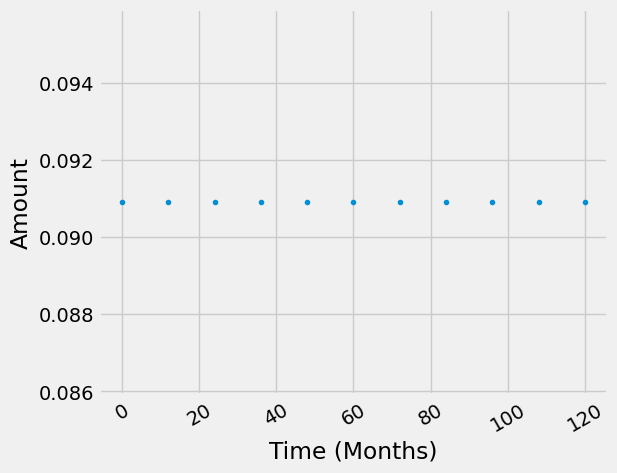

In [154]:
elec_MY = 10

td_elec = easy_timedelta_distribution(
    start=0,
    end=elec_MY,
    resolution="Y",
    steps=(elec_MY + 1),
    kind="uniform",  
)
td_elec.graph(resolution="M") # here month resolution, so later tlca.build_timeline(temporal_grouping="month") 

In [155]:
input_elec_to_highvol_CAN_1kwh["temporal_distribution"] = td_elec
input_elec_to_highvol_CAN_1kwh.save()

## map to background premise

In [156]:
database_dates = {
    image_ssp1_db_2030.name: datetime.strptime("2030", "%Y"),
    #image_ssp1_db_2040.name: datetime.strptime("2040", "%Y"),
    #image_ssp1_db_2050.name: datetime.strptime("2050", "%Y"),
    "elec_foreground": "dynamic", # flag databases that should be temporally distributed with "dynamic"
}

database_dates

{'ei_cutoff_3.11_image_SSP1-VLLO_2030 2025-11-24': datetime.datetime(2030, 1, 1, 0, 0),
 'elec_foreground': 'dynamic'}

In [157]:
method = ('ecoinvent-3.11', 'CML v4.8 2016', 'climate change', 'global warming potential (GWP100)') 

In [158]:
tlca = TimexLCA({elec_highvol_CAN_1kwh: 1}, method, database_dates)

2025-11-24 13:13:46.610 | INFO     | bw_timex.timex_lca:__init__:114 - Initializing TimexLCA object...
2025-11-24 13:13:46.613 | INFO     | bw_timex.timex_lca:__init__:136 - Collecting node infos...


In [159]:
# build a timeline of the exchanges:
tlca.build_timeline(temporal_grouping="month")

2025-11-24 13:14:20.567 | INFO     | bw_timex.timex_lca:build_timeline:216 - No edge filter function provided. Skipping all edges in background databases.
2025-11-24 13:14:24.184 | INFO     | bw_timex.timex_lca:build_timeline:232 - Calculating base LCA...
2025-11-24 13:14:32.122 | INFO     | bw_timex.timex_lca:build_timeline:242 - Creating activity time mapping...
2025-11-24 13:14:32.350 | INFO     | bw_timex.timeline_builder:__init__:99 - Traversing supply chain graph...


Starting graph traversal


2025-11-24 13:14:46.529 | INFO     | bw_timex.timeline_builder:build_timeline:142 - Building timeline...
2025-11-24 13:14:46.566 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:522 - Reference date 2025-12-01 00:00:00 is lower than all provided dates. Data will be taken from the closest higher year.
2025-11-24 13:14:46.566 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:522 - Reference date 2025-12-01 00:00:00 is lower than all provided dates. Data will be taken from the closest higher year.
2025-11-24 13:14:46.567 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:522 - Reference date 2026-12-01 00:00:00 is lower than all provided dates. Data will be taken from the closest higher year.
2025-11-24 13:14:46.567 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:522 - Reference date 2027-12-01 00:00:00 is lower than all prov

Calculation count: 1


,date_producer,producer_name,date_consumer,consumer_name,amount,temporal_market_shares
0,2025-12-01,"market group for electricity, high voltage",2025-12-01,"electricity mix, high voltage, Canada",0.090909,{'ei_cutoff_3.11_image_SSP1-VLLO_2030 2025-11-...
1,2025-12-01,"electricity mix, high voltage, Canada",2025-12-01,-1,1.0,None
2,2026-12-01,"market group for electricity, high voltage",2025-12-01,"electricity mix, high voltage, Canada",0.090909,{'ei_cutoff_3.11_image_SSP1-VLLO_2030 2025-11-...
3,2027-12-01,"market group for electricity, high voltage",2025-12-01,"electricity mix, high voltage, Canada",0.090909,{'ei_cutoff_3.11_image_SSP1-VLLO_2030 2025-11-...
4,2028-12-01,"market group for electricity, high voltage",2025-12-01,"electricity mix, high voltage, Canada",0.090909,{'ei_cutoff_3.11_image_SSP1-VLLO_2030 2025-11-...
5,2029-12-01,"market group for electricity, high voltage",2025-12-01,"electricity mix, high voltage, Canada",0.090909,{'ei_cutoff_3.11_image_SSP1-VLLO_2030 2025-11-...
6,2030-12-01,"market group for electricity, high voltage",2025-12-01,"electricity mix, high voltage, Canada",0.090909,{'ei_cutoff_3.11_image_SSP1-VLLO_2030 2025-11-...
7,2031-12-01,"market group for electricity, high voltage",2025-12-01,"electricity mix, high voltage, Canada",0.090909,{'ei_cutoff_3.11_image_SSP1-VLLO_2030 2025-11-...
8,2032-12-01,"market group for electricity, high voltage",2025-12-01,"electricity mix, high voltage, Canada",0.090909,{'ei_cutoff_3.11_image_SSP1-VLLO_2030 2025-11-...
9,2033-12-01,"market group for electricity, high voltage",2025-12-01,"electricity mix, high voltage, Canada",0.090909,{'ei_cutoff_3.11_image_SSP1-VLLO_2030 2025-11-...


In [160]:
#then calculate the time-explicit LCI, with TimexLCA.lci()
tlca.lci()

2025-11-24 13:15:22.857 | INFO     | bw_timex.timex_lca:lci:360 - Expanding matrices...
2025-11-24 13:15:22.886 | INFO     | bw_timex.timex_lca:lci:379 - Calculating dynamic inventory...
/Users/susierwu/miniconda3/envs/bw2_timex_env/lib/python3.12/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:603: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve


In [162]:
tlca.dynamic_inventory # the new dynamic_inventory that was now created, we can see that it has more rows (emissions) than our usual biosphere3 flows. Instead of one row for each emission in the biosphere database we now get one row for each emission at each point in time.


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 31911 stored elements and shape (36102, 41787)>

In [165]:
tlca.dynamic_inventory.shape

(36102, 41787)

In [166]:
#the dynamic inventory is calculated as a sparse matrix, more human-friendly version as a pandas:
tlca.dynamic_inventory_df

,date,amount,flow,activity
2305,2025-12-01,7.791618e+00,250401799139369058,251340274252521474
632,2025-12-01,5.846128e+00,250401797902049299,251340274252521474
286,2025-12-01,1.454676e+00,250401797688139822,251340274252521474
279,2025-12-01,4.261160e-01,250401797688139804,251340274252521474
1392,2025-12-01,4.255473e-01,250401798346645610,251340274252521474
...,...,...,...,...
29275,2035-12-01,-7.884495e-20,250401797683945486,251340274252521485
30561,2035-12-01,-2.118683e-19,250401798514417664,251340274252521485
31150,2035-12-01,-8.184842e-13,250401799005151256,251340274252521485
31380,2035-12-01,-2.532450e-12,250401799198089261,251340274252521485


In [167]:
mybio = bw2data.Database('ecoinvent-3.11-biosphere')

[]

In [171]:
[x for x in mybio if 'Carbon dioxide, fossil' in str(x)][0].as_dict()

{'categories': ('air',),
 'code': '349b29d1-3e58-4c66-98b9-9d1a076efd2e',
 'CAS number': '000124-38-9',
 'synonyms': ['Carbon dioxide'],
 'name': 'Carbon dioxide, fossil',
 'database': 'ecoinvent-3.11-biosphere',
 'unit': 'kilogram',
 'type': 'emission',
 'id': 250401798669606930}

In [179]:
flow_id = '250401797688139804' 

[x for x in mybio if str(x.as_dict()['id']) == str(flow_id)]


['Water, turbine use, unspecified natural origin' (cubic meter, None, ('natural resource', 'in water'))]